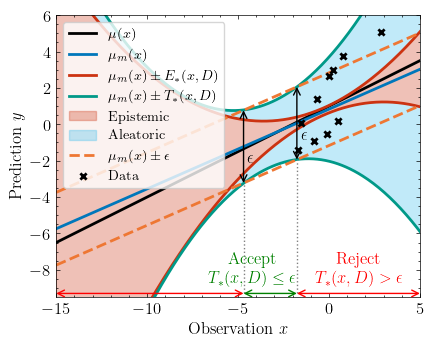

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('halfstyle.mplstyle')

# Get the color cycle from the active style
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
green = 'green'
red = 'red'
epistemic_color = colors[5]

xlim = [-15, 5]
# GT model mean
k0 = 1 
k1 = 0.5
# GT model variance
c0 = 0.1
c1 = 0.04
offset = 8

tau2_intercept = 1
tau2_slope = 0.1


seed = 12
np.random.seed(seed) # for reproducibility
num_samples = 10

X_features = np.random.normal(loc=0, scale=1, size=num_samples)

# Rejection cost epsilon
total_reject_cost_epsilon = 2
epistemic_reject_cost_delta = 1
epsilon = 1.

# X-axis annotations for Accept/Reject regions
# Position the arrows below the x-axis line
y_lim_bottom = -9.5
y_lim_top = 6
y_arrow_pos = -9.3

def true_mean_model(x):
    """ The optimal predictor h*(x), which is the conditional mean E[y|x]. """
    return k0 + k1 * x

def aleatoric_variance_model(x):
    """ The conditional risk r*(x), which for L2 loss is the variance Var(y|x). """
    return c0 + c1 * (x + offset)**2

def aleatoric_std_dev(x):
    """ The standard deviation sqrt(Var(y|x)), for visualization purposes. """
    return np.sqrt(aleatoric_variance_model(x))


# 3. Generate data for plotting
x_range = np.linspace(xlim[0], xlim[1], 500)
mean_vals = true_mean_model(x_range)
std_var_vals = aleatoric_variance_model(x_range)

sigma2_observations = aleatoric_variance_model(X_features)
noise_obs = np.random.normal(0, np.sqrt(sigma2_observations), num_samples)
y_observations = true_mean_model(X_features) + noise_obs

# Perform Bayesian Linear Regression to learn a model
X_design = np.vstack((np.ones(num_samples), X_features)).T
num_model_params = X_design.shape[1]

# Manually construct the diagonal prior covariance matrix
Sigma_prior = np.diag([tau2_intercept, tau2_slope])
Sigma_prior_inv = np.linalg.inv(Sigma_prior)

S_inv_diag = 1.0 / sigma2_observations

XT_S_inv_X = (X_design.T * S_inv_diag) @ X_design
XT_S_inv_y = (X_design.T * S_inv_diag) @ y_observations
Sigma_post = np.linalg.inv(Sigma_prior_inv + XT_S_inv_X)
mu_post = Sigma_post @ XT_S_inv_y

epsilon_boundary_on_plot = total_reject_cost_epsilon

# --- Calculate Predictive Quantities for Plotting ---
x_range = np.linspace(-15, 15, 400)

# Instead of GT mean, we now have a learned predictive mean
y_mean_pred = np.zeros_like(x_range)
epistemic_variance = np.zeros_like(x_range)
aleatoric_variance = np.zeros_like(x_range)

for i, x_val in enumerate(x_range):
    x_new_design = np.array([1, x_val])
    y_mean_pred[i] = x_new_design @ mu_post
    epistemic_variance[i] = x_new_design @ Sigma_post @ x_new_design.T
    aleatoric_variance[i] = aleatoric_variance_model(x_val)

# Convert all variances to standard deviations
epistemic_std_dev = np.sqrt(epistemic_variance)
total_variance = epistemic_variance + aleatoric_variance
total_std_dev = np.sqrt(total_variance)

# --- Determine transition points ---
epistemic_reject_mask = epistemic_variance > epistemic_reject_cost_delta
epistemic_transitions = x_range[np.where(np.diff(epistemic_reject_mask))[0]]

total_reject_mask = total_variance > total_reject_cost_epsilon
total_transitions = x_range[np.where(np.diff(total_reject_mask))[0]]

# --- Create the Plot ---
fig, ax = plt.subplots(figsize=(4.5, 5.625), constrained_layout=True)

# 2. Plot Lines and Data
ax.plot(x_range, true_mean_model(x_range), color='k', linestyle='-', label='$\\mu(x)$')
ax.plot(x_range, y_mean_pred, color=colors[1], linestyle='-', label='$\\mu_m(x)$')

ax.plot(x_range, y_mean_pred - epistemic_variance, linestyle='-', color=colors[4])
ax.plot(x_range, y_mean_pred + epistemic_variance, linestyle='-', label="$\\mu_m(x) \pm E_*(x,D)$", color=colors[4])

ax.plot(x_range, y_mean_pred - total_std_dev**2, linestyle='-', color=epistemic_color)
ax.plot(x_range, y_mean_pred + total_std_dev**2, linestyle='-', label="$\\mu_m(x) \pm T_*(x,D)$", color=epistemic_color)

ax.fill_between(x_range, y_mean_pred - epistemic_variance,  y_mean_pred + epistemic_variance, linestyle='-', color=colors[4], alpha=0.3)
ax.fill_between(x_range, y_mean_pred - epistemic_variance - aleatoric_variance,  y_mean_pred - epistemic_variance, linestyle='-', color=colors[2], alpha=0.3)
ax.fill_between(x_range, y_mean_pred + epistemic_variance,  y_mean_pred + epistemic_variance + aleatoric_variance, linestyle='-', color=colors[2], alpha=0.3)

ax.fill_between(x_range - 100, y_mean_pred - epistemic_variance,  y_mean_pred + epistemic_variance, linestyle='-', color=colors[4], alpha=0.3, label="Epistemic")
ax.fill_between(x_range - 100, y_mean_pred - epistemic_variance - aleatoric_variance,  y_mean_pred - epistemic_variance, linestyle='-', color=colors[2], alpha=0.3, label="Aleatoric")

ax.plot(x_range, y_mean_pred + epsilon_boundary_on_plot, linestyle='--', label='$\\mu_m(x) \pm \\epsilon$', color=colors[0])
ax.plot(x_range, y_mean_pred - epsilon_boundary_on_plot, linestyle='--', color=colors[0])

ax.scatter(X_features, y_observations, marker='x', color='k', s=20, zorder=10, label='Data')

x_transition1, x_transition2 = total_transitions

# Accept arrow
ax.annotate('', xy=(x_transition1, y_arrow_pos), xytext=(x_transition2, y_arrow_pos),
            arrowprops=dict(arrowstyle='<->', color=green, shrinkA=0, shrinkB=0))
ax.text((x_transition1 + x_transition2) / 2 - (x_transition2 - x_transition1)/3, y_arrow_pos + 0.4, 'Accept\n$T_*(x,D) \leq \\epsilon$',
        ha='center', va='bottom', color=green)

# Reject arrows
ax.annotate('', xy=(xlim[0], y_arrow_pos), xytext=(x_transition1, y_arrow_pos),
            arrowprops=dict(arrowstyle='<->', color=red, shrinkA=0, shrinkB=0))
ax.annotate('', xy=(x_transition2, y_arrow_pos), xytext=(xlim[1], y_arrow_pos),
            arrowprops=dict(arrowstyle='<->', color=red, shrinkA=0, shrinkB=0))
ax.text(x_transition2 + (xlim[1]-x_transition2)/2, y_arrow_pos + 0.4, 'Reject\n$T_*(x,D) > \\epsilon$',
        ha='center', va='bottom', color=red)


for label_x_pos in [x_transition1, x_transition2]:
    mean_at_label_pos = np.interp(label_x_pos, x_range, y_mean_pred)
    ax.annotate('', xy=(label_x_pos, mean_at_label_pos - epsilon_boundary_on_plot),
                xytext=(label_x_pos, mean_at_label_pos + epsilon_boundary_on_plot),
                arrowprops=dict(arrowstyle='<->', color='k', shrinkA=0, shrinkB=0))
    ax.text(label_x_pos + 0.2, mean_at_label_pos - 0.65, '$\\epsilon$',
            verticalalignment='center', horizontalalignment='left')
    ax.plot([label_x_pos, label_x_pos], [y_arrow_pos, mean_at_label_pos - epsilon_boundary_on_plot],
            color='gray', linestyle='dotted', linewidth=1)



ax.set_xlabel('Observation $x$')
ax.set_ylabel('Prediction $y$')
ax.legend(loc='upper left', ncols=1, fontsize='small') # The legend looks better with 2 columns, placed at bbox_to_anchor=[0.025, 1.41], and with standard font size. But due to size restrictions of the venue, we modify it
ax.set_xlim(xlim)
ax.set_ylim(bottom=y_lim_bottom, top=y_lim_top)
ax.set_aspect(1)
plt.tight_layout()
plt.savefig("figure_total.pdf", dpi=400, bbox_inches='tight')
plt.show()